[Info] Loaded 15248 valid scores, skipped 0, out_of_range 0

📊 Basic Statistics:
  count   : 15248
  mean    : -0.0012
  std     : 0.0403
  min     : -0.7436
  max     : 0.5162
  median  : 0.0000
  q1      : 0.0000
  q3      : 0.0000

Interval              Count   Percentage
------------------------------------------------------------
[-1.0, -0.9)              0        0.00%
[-0.9, -0.8)              0        0.00%
[-0.8, -0.7)              1        0.01%
[-0.7, -0.6)              2        0.01%
[-0.6, -0.5)             20        0.13%
[-0.5, -0.4)             15        0.10%
[-0.4, -0.3)             13        0.09%
[-0.3, -0.2)              9        0.06%
[-0.2, -0.1)             81        0.53%
[-0.1, -0.0)            994        6.52%
[-0.0, 0.1)           14026       91.99%
[0.1, 0.2)               37        0.24%
[0.2, 0.3)               12        0.08%
[0.3, 0.4)               14        0.09%
[0.4, 0.5)               20        0.13%
[0.5, 0.6)                4        0.03%
[0.6, 0

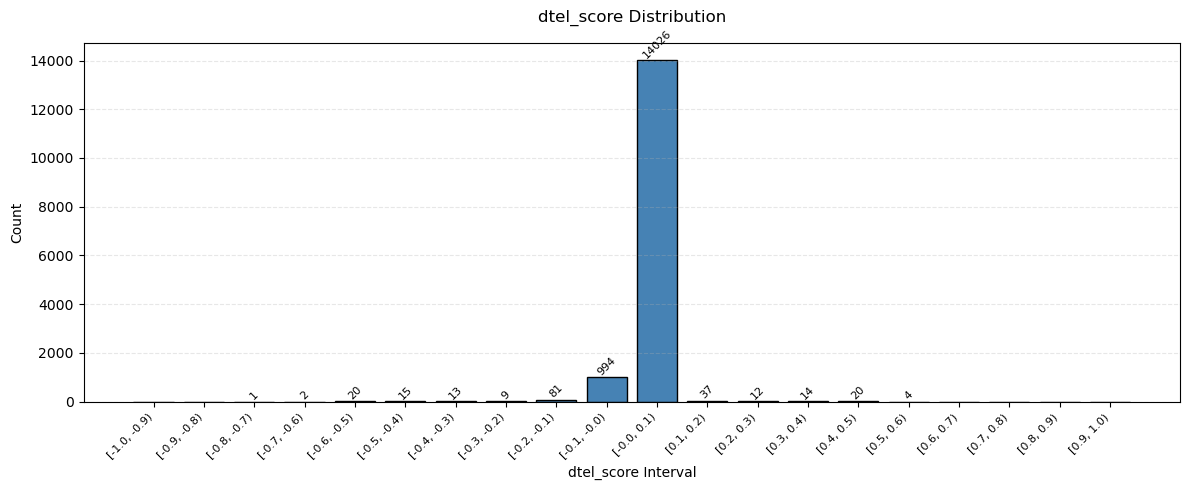

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
统计 JSONL 文件中 dtel_score 字段的分布（区间宽度=0.1）
"""

import json
import math
from collections import defaultdict
from pathlib import Path
from typing import List, Dict, Optional

import numpy as np

# 可选：可视化依赖（pip install matplotlib）
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False


def load_dtel_scores(jsonl_path: str, field: str = "dtel_score") -> List[float]:
    """
    从 JSONL 文件中提取指定字段的数值列表
    
    自动处理：
    - 缺失字段 / None 值
    - 非数值类型
    - 超出 [-1, 1] 范围的异常值（记录警告）
    """
    scores = []
    skipped = 0
    out_of_range = 0
    
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                val = obj.get(field)
                
                # 跳过 None 或缺失
                if val is None:
                    skipped += 1
                    continue
                
                # 尝试转为 float
                score = float(val)
                
                # 检查范围
                if not (-1.0 <= score <= 1.0):
                    out_of_range += 1
                    print(f"[Warn] Line {line_num}: {field}={score} out of [-1,1], clipped")
                    score = max(-1.0, min(1.0, score))  # 裁剪到合法范围
                
                scores.append(score)
                
            except (json.JSONDecodeError, ValueError, TypeError) as e:
                skipped += 1
                if line_num <= 5:  # 仅打印前几个错误，避免刷屏
                    print(f"[Warn] Line {line_num} skipped: {e}")
    
    print(f"[Info] Loaded {len(scores)} valid scores, skipped {skipped}, out_of_range {out_of_range}")
    return scores


def bin_dtel_scores(scores: List[float], bin_width: float = 0.1) -> Dict[str, Dict]:
    """
    按指定区间宽度分桶统计
    
    Returns:
        {
            "bin_label": {
                "count": int,
                "percentage": float,  # 占总数的百分比
                "bin_range": (low, high)
            },
            ...
        }
    """
    if not scores:
        return {}
    
    # 生成区间边界：[-1.0, -0.9), [-0.9, -0.8), ..., [0.9, 1.0]
    # 注意：最后一个区间右闭，避免 1.0 被遗漏
    bins = np.arange(-1.0, 1.0 + bin_width/2, bin_width)  # [-1.0, -0.9, ..., 1.0]
    bin_counts = defaultdict(int)
    
    for s in scores:
        # 使用 np.digitize 确定区间索引
        idx = np.digitize(s, bins) - 1
        # 边界处理：1.0 会被分到最后一个区间
        idx = min(idx, len(bins) - 2)
        
        low = bins[idx]
        high = bins[idx + 1]
        # 格式化标签：[-1.0, -0.9) → "[-1.0, -0.9)"
        label = f"[{low:.1f}, {high:.1f})" if high < 1.0 else f"[{low:.1f}, {high:.1f}]"
        bin_counts[label] += 1
    
    total = len(scores)
    result = {}
    # 按区间顺序输出
    for i in range(len(bins) - 1):
        low, high = bins[i], bins[i+1]
        label = f"[{low:.1f}, {high:.1f})" if high < 1.0 else f"[{low:.1f}, {high:.1f}]"
        count = bin_counts.get(label, 0)
        result[label] = {
            "count": count,
            "percentage": round(count / total * 100, 2),
            "bin_range": (low, high)
        }
    
    return result


def print_distribution(dist: Dict[str, Dict], top_n: Optional[int] = None):
    """
    打印分布表格（支持按数量排序）
    """
    if not dist:
        print("[Warn] Empty distribution")
        return
    
    # 按区间顺序排序（而非字母序）
    sorted_bins = sorted(dist.items(), key=lambda x: x[1]["bin_range"][0])
    if top_n:
        sorted_bins = sorted(sorted_bins, key=lambda x: x[1]["count"], reverse=True)[:top_n]
    
    print("\n" + "="*60)
    print(f"{'Interval':<18} {'Count':>8} {'Percentage':>12}")
    print("-"*60)
    
    total_count = sum(v["count"] for v in dist.values())
    for label, stats in sorted_bins:
        if stats["count"] > 0 or top_n is None:  # 跳过空桶（除非显示全部）
            print(f"{label:<18} {stats['count']:8d} {stats['percentage']:11.2f}%")
    
    print("-"*60)
    print(f"{'Total':<18} {total_count:8d} {'100.00':>11}%")
    print("="*60 + "\n")


def plot_distribution(dist: Dict[str, Dict], save_path: Optional[str] = None, title: str = "dtel_score Distribution"):
    """
    绘制分布直方图（需 matplotlib）
    """
    if not HAS_MATPLOTLIB:
        print("[Warn] matplotlib not installed, skip plotting. Run: pip install matplotlib")
        return
    
    # 准备数据
    labels = []
    counts = []
    for label in sorted(dist.keys(), key=lambda x: dist[x]["bin_range"][0]):
        labels.append(label)
        counts.append(dist[label]["count"])
    
    if not counts:
        print("[Warn] No data to plot")
        return
    
    # 绘图
    plt.figure(figsize=(12, 5))
    bars = plt.bar(labels, counts, color="steelblue", edgecolor="black", width=0.8)
    
    # 添加数值标签
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height)}", 
                    ha="center", va="bottom", fontsize=8, rotation=45)
    
    plt.xlabel("dtel_score Interval", fontsize=10)
    plt.ylabel("Count", fontsize=10)
    plt.title(title, fontsize=12, pad=15)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[Info] Plot saved to {save_path}")
    else:
        plt.show()


def compute_statistics(scores: List[float]) -> Dict[str, float]:
    """计算基础统计量"""
    if not scores:
        return {}
    arr = np.array(scores)
    return {
        "count": len(arr),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "median": float(np.median(arr)),
        "q1": float(np.percentile(arr, 25)),
        "q3": float(np.percentile(arr, 75)),
    }


def main():
    # ================= 配置区域 =================
    jsonl_path = "/data1/home/dataset_share/cd_data/Qwen2.5-VL-7B/EarthVQA/final/detect_EarthVQA_Qwen_with_sem_128.jsonl"  # 🔴 修改为你的文件路径
    output_plot = "dtel_score_dist.png"       # 可选：保存图表，设为 None 则不保存
    show_plot = True                           # 是否显示图表（需 GUI 环境）
    bin_width = 0.1                            # 区间宽度
    # ===========================================
    
    # 1. 加载数据
    scores = load_dtel_scores(jsonl_path)
    if not scores:
        print("[Error] No valid scores found. Exit.")
        return
    
    # 2. 基础统计
    stats = compute_statistics(scores)
    print("\n📊 Basic Statistics:")
    for k, v in stats.items():
        print(f"  {k:8s}: {v:.4f}" if isinstance(v, float) else f"  {k:8s}: {v}")
    
    # 3. 分桶统计
    dist = bin_dtel_scores(scores, bin_width=bin_width)
    print_distribution(dist)
    
    # 4. 可视化（可选）
    if HAS_MATPLOTLIB and (show_plot or output_plot):
        plot_distribution(dist, save_path=output_plot if output_plot else None)


if __name__ == "__main__":
    main()